In [1]:
import sys

import json
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from pathlib import Path

In [2]:
MODULES_PATH = Path("../modules").resolve()

if str(MODULES_PATH) not in sys.path:
    sys.path.insert(0, str(MODULES_PATH))

from plotting import format_axes

In [3]:
metrics = {}

for id in range(1, 12):
    with open(f"../../data/results/epis/biored_dev/epi_{id:03d}.json", "r") as f:
        data = json.load(f)
        epi_metrics = data["metrics"]

    metrics[f"epi_{id:03d}"] = epi_metrics

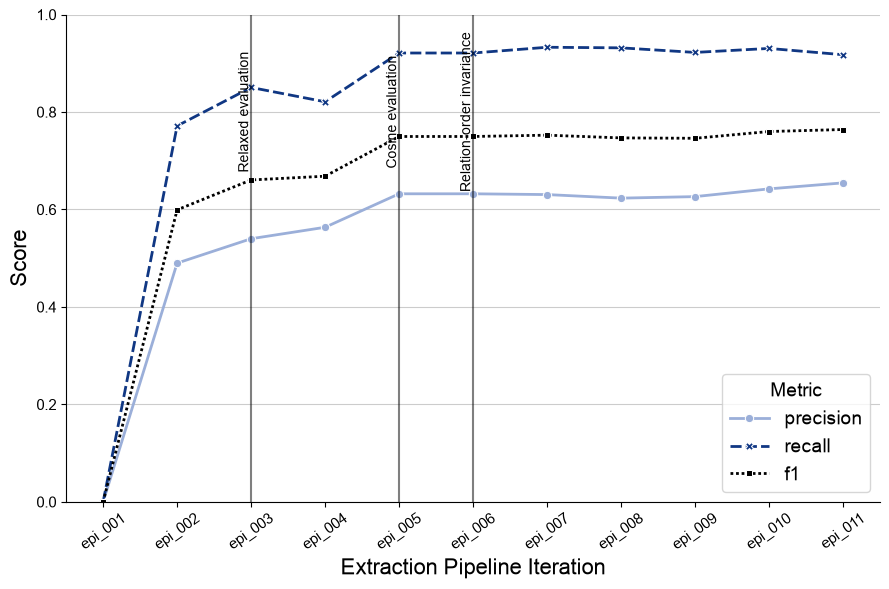

In [4]:
plt.rcParams["font.family"] = "arial"

MATCH_ORDER = ["strict", "relaxed", "cosine"]

def latest_match_type(type_dict):
    """Return the most recent match type present for this entry."""
    for match_type in reversed(MATCH_ORDER):
        if match_type in type_dict:
            return match_type
    return None

def build_long_df(metrics, category="entity"):
    """category = "entity" or "relation"""
    rows = []
    for epi_id, epi_data in metrics.items():
        type_dict = epi_data.get(category, {})
        match_type = latest_match_type(type_dict)
        if match_type is None:
            continue
        scores = type_dict[match_type]
        for metric_name in ["precision", "recall", "f1"]:
            rows.append({
                "epi_id": epi_id,
                "match_type": match_type,
                "metric": metric_name,
                "value": scores[metric_name]
            })
    return pd.DataFrame(rows)

entity_df = build_long_df(metrics, category="entity")

fig, ax = plt.subplots(figsize=(9, 6))

ax = sns.lineplot(
    data=entity_df,
    x="epi_id",
    y="value",
    hue="metric",
    style="metric",
    markers=True,
    dashes=True,
    linewidth=2,
    palette=["#9bafd9", "#103783", "#000000"]
)

for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)

ax.grid(axis="y", color="black", alpha=0.2)

ax.set_ylabel("Score", fontsize=16)
ax.set_xlabel("Extraction Pipeline Iteration", fontsize=16)
ax.tick_params(labelrotation=35, axis="x")
ax.tick_params(labelsize=11)
ax.set_ylim(0, 1)

for id, label in zip(("003",  "005", "006"), ("Relaxed evaluation", "Cosine evaluation", "Relation-order invariance")):
    ax.axvline(f"epi_{id}", color="black", alpha=0.5)

    ax.text(
        f"epi_{id}",
        0.8,
        label,
        transform=ax.get_xaxis_transform(),
        rotation=90,
        ha="right",
        va="center"
    )

plt.legend(title="Metric", title_fontsize=14, fontsize=14)
fig.tight_layout()

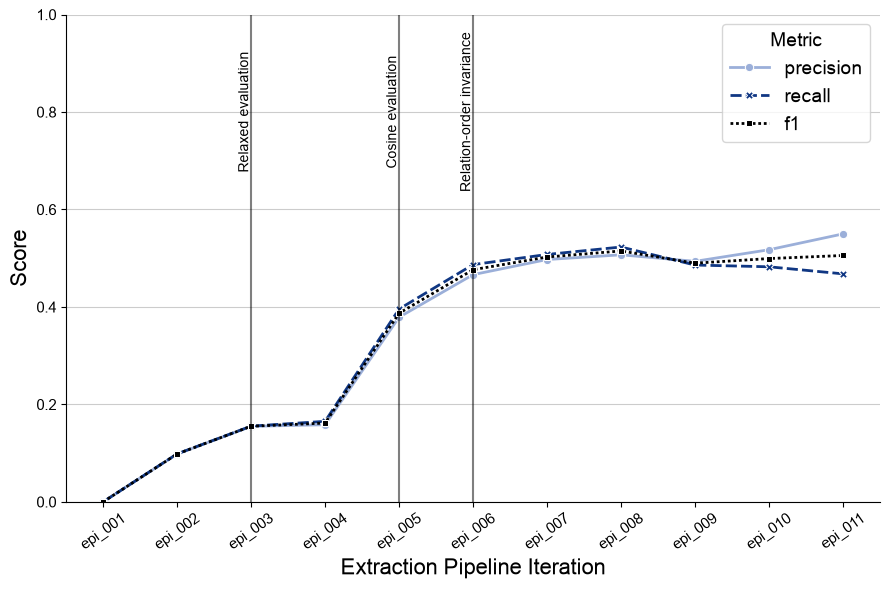

In [5]:
plt.rcParams["font.family"] = "arial"

MATCH_ORDER = ["strict", "relaxed", "cosine"]

relation_df = build_long_df(metrics, category="relation")

fig, ax = plt.subplots(figsize=(9, 6))

ax = sns.lineplot(
    data=relation_df,
    x="epi_id",
    y="value",
    hue="metric",
    style="metric",
    markers=True,
    dashes=True,
    linewidth=2,
    palette=["#9bafd9", "#103783", "#000000"]
)

for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)

ax.grid(axis="y", color="black", alpha=0.2)

ax.set_ylabel("Score", fontsize=16)
ax.set_xlabel("Extraction Pipeline Iteration", fontsize=16)
ax.tick_params(labelrotation=35, axis="x")
ax.tick_params(labelsize=11)
ax.set_ylim(0, 1)

for id, label in zip(("003",  "005", "006"), ("Relaxed evaluation", "Cosine evaluation", "Relation-order invariance")):
    ax.axvline(f"epi_{id}", color="black", alpha=0.5)

    ax.text(
        f"epi_{id}",
        0.8,
        label,
        transform=ax.get_xaxis_transform(),
        rotation=90,
        ha="right",
        va="center"
    )

plt.legend(title="Metric", title_fontsize=14, fontsize=14)
fig.tight_layout()

In [31]:
wide_relation_df = relation_df.pivot(
    index=['epi_id', 'match_type'],
    columns='metric',
    values='value'
).reset_index()

wide_relation_df.columns.name = None

sorted_wide_relation_df = wide_relation_df.sort_values(by="f1",axis=0, ascending=False).iloc[:3]

sorted_wide_relation_df

,epi_id,match_type,f1,precision,recall
7,epi_008,cosine,0.5149,0.5070,0.5230
10,epi_011,cosine,0.5056,0.5499,0.4679
6,epi_007,cosine,0.5025,0.4973,0.5077


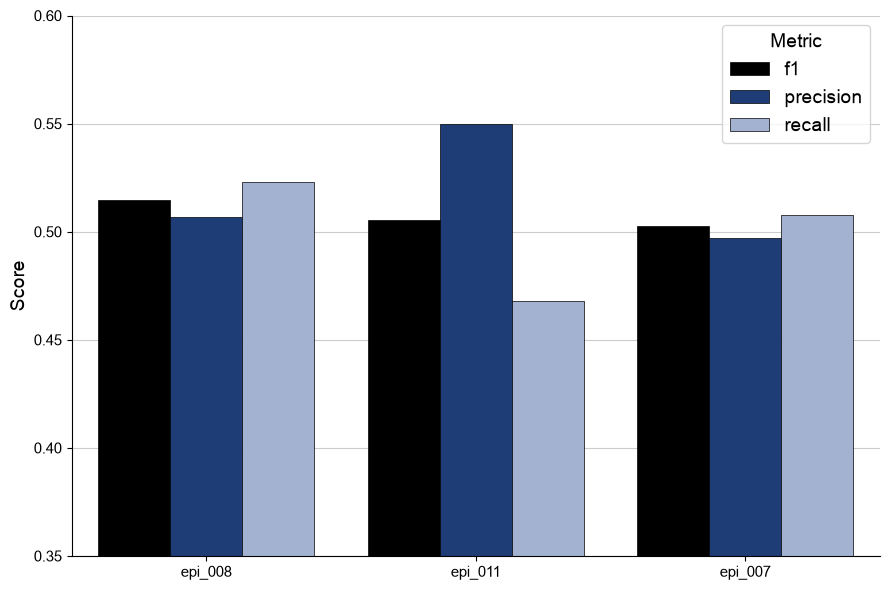

In [ ]:
melted_relation_df = sorted_wide_relation_df.drop("match_type", axis=1).melt(id_vars="epi_id", var_name="metric")

fig, ax = plt.subplots(figsize=(9,6))

ax = sns.barplot(
    data=melted_relation_df,
    x="epi_id", y="value",
    hue="metric",
    edgecolor="black",
    linewidth=0.5,
    palette=["#000000", "#103783", "#9bafd9"]
)

ax.set_ylim((0.35, 0.6))
ax.set_xlabel("")
ax.set_ylabel("Score", fontsize=14)
ax.tick_params(labelsize=11)

ax.set_axisbelow(True)
ax.grid(axis="y", color="black", alpha=0.2)

for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)

plt.legend(title="Metric", title_fontsize=14, fontsize=14)

fig.tight_layout()